
# Customer Segmentation Analysis — Olist E-Commerce

## Objective

Segment 93,000+ customers of a Brazilian e-commerce marketplace into actionable groups based on purchasing behavior, delivery experience, geographic location, and satisfaction — enabling targeted marketing strategies and operational improvements.

## Dataset

The [Olist Brazilian E-Commerce Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) contains ~100K orders from 2016–2018 across 9 relational tables covering orders, customers, products, payments, reviews, sellers, and geolocation.

## Methodology

1. **Data Cleaning & Merging** — Filtered to delivered orders, resolved nulls, built a unified order-item dataframe
2. **Customer-Level Aggregation** — Collapsed to one row per unique customer with 16 behavioral features
3. **EDA** — Identified skewness, multicollinearity, and near-zero variance features
4. **Feature Preparation** — Log transforms, StandardScaler, feature selection (9 final features)
5. **Clustering** — K-Means (primary), Hierarchical (validation), DBSCAN (density check)
6. **Profiling** — Named segments with business strategies

## Key Finding

Four distinct customer segments emerged, validated across two independent algorithms, each requiring a different business strategy — from upselling to satisfied casual buyers, to urgent recovery campaigns for dissatisfied at-risk customers.


In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Scipy
import scipy.cluster.hierarchy as sch

## Phase 1 — Data Loading


In [2]:
data_path = "../data/"
customer_df = pd.read_csv(f"{data_path}olist_customers_dataset.csv")
geolocation_df = pd.read_csv(f"{data_path}olist_geolocation_dataset.csv")
items_df = pd.read_csv(f"{data_path}olist_order_items_dataset.csv")
payments_df = pd.read_csv(f"{data_path}olist_order_payments_dataset.csv")
reviews_df = pd.read_csv(f"{data_path}olist_order_reviews_dataset.csv")
orders_df = pd.read_csv(f"{data_path}olist_orders_dataset.csv")
products_df = pd.read_csv(f"{data_path}olist_products_dataset.csv")
sellers_df = pd.read_csv(f"{data_path}olist_sellers_dataset.csv")
category_product_df = pd.read_csv(f"{data_path}product_category_name_translation.csv")

df_list =[customer_df, geolocation_df, items_df, payments_df, reviews_df, orders_df, products_df, sellers_df, category_product_df]
keys = str.split("customer_df, geolocation_df, items_df, payments_df, reviews_df, orders_df, products_df, sellers_df, category_product_df",sep = ', ')
df_dict = dict(zip(keys, df_list))

In [3]:
for k,v in df_dict.items():
    print(f"the columns of {k} are",v.columns.to_list())
    print(f"the shape of {k} is",v.shape)
    print()


#each dataset information and structure
for k,v in df_dict.items():
    print(f"{k}:-")
    print(v.info())
    print('*-'*76)

the columns of customer_df are ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
the shape of customer_df is (99441, 5)

the columns of geolocation_df are ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
the shape of geolocation_df is (1000163, 5)

the columns of items_df are ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
the shape of items_df is (112650, 7)

the columns of payments_df are ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
the shape of payments_df is (103886, 5)

the columns of reviews_df are ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
the shape of reviews_df is (99224, 7)

the columns of orders_df are ['order_id', 'customer_id', 'order_status', 'order_purchase_t

## Phase 2 — Data Cleaning & Merging

**Cleaning decisions:**
- Filtered `orders_df` to `delivered` status only (~96K orders) — undelivered orders add noise to behavioral segmentation
- Merged `products_df` with category translation for English names; dropped listing metadata columns (name length, description length, photo count)
- Aggregated `payments_df` to order level: total payment, dominant type (mode), max installments
- Aggregated `reviews_df` to mean score per order (resolving ~550 duplicate review entries)
- Cleaned `geolocation_df` to Brazil's geographic bounds (lat: -33.75 to 5.27, lng: -73.99 to -34.79), removing 42 erroneous coordinates
- Built `geo_lookup` table with median lat/lng per zip code prefix (~19K unique locations)

In [4]:
display(reviews_df.info())
reviews_df = reviews_df.fillna("unknown")
reviews_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


None

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,unknown,unknown,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,unknown,unknown,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,unknown,unknown,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,unknown,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,unknown,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [5]:
orders_df = orders_df.loc[orders_df.order_status == 'delivered']
orders_df = orders_df.dropna()
display(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96455 non-null  object
 1   customer_id                    96455 non-null  object
 2   order_status                   96455 non-null  object
 3   order_purchase_timestamp       96455 non-null  object
 4   order_approved_at              96455 non-null  object
 5   order_delivered_carrier_date   96455 non-null  object
 6   order_delivered_customer_date  96455 non-null  object
 7   order_estimated_delivery_date  96455 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


None

In [6]:
merged_products_df = pd.merge(products_df, category_product_df, on="product_category_name",how="left")
merged_products_df = merged_products_df.loc[:,['product_id','product_category_name_english','product_weight_g',
                          'product_length_cm','product_height_cm','product_width_cm']]  #dropping unnecsssary products

merged_products_df['product_category_name_english'] = merged_products_df.product_category_name_english.fillna("Unknown")
merged_products_df['product_weight_g'] = merged_products_df.product_weight_g.fillna('mean')
merged_products_df['product_length_cm'] = merged_products_df.product_length_cm.fillna('mean')
merged_products_df['product_height_cm'] = merged_products_df.product_height_cm.fillna('mean')
merged_products_df['product_width_cm'] = merged_products_df.product_width_cm.fillna('mean')

products_df = merged_products_df.copy()
display(products_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_id                     32951 non-null  object
 1   product_category_name_english  32951 non-null  object
 2   product_weight_g               32951 non-null  object
 3   product_length_cm              32951 non-null  object
 4   product_height_cm              32951 non-null  object
 5   product_width_cm               32951 non-null  object
dtypes: object(6)
memory usage: 1.5+ MB


None

In [7]:
reviews_df = reviews_df.loc[:,['order_id','review_score']]

In [8]:
items_df.shipping_limit_date = pd.to_datetime(items_df['shipping_limit_date'])
cols_to_fix = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Use apply to convert all selected columns to datetime
orders_df[cols_to_fix] = orders_df[cols_to_fix].apply(pd.to_datetime)

cols_to_fix = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Use apply to convert all selected columns to datetime
# Use a lambda to pass each column (x) into the function
products_df[cols_to_fix] = products_df[cols_to_fix].apply(lambda x: pd.to_numeric(x, errors='coerce'))

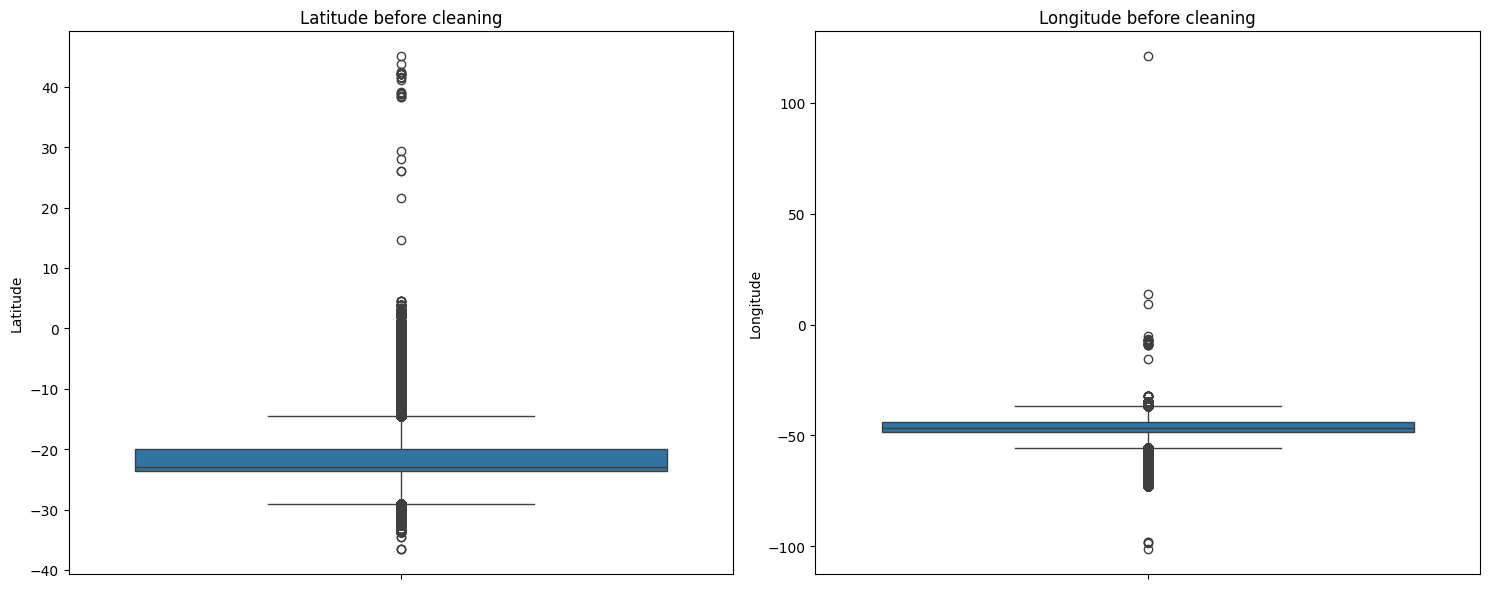

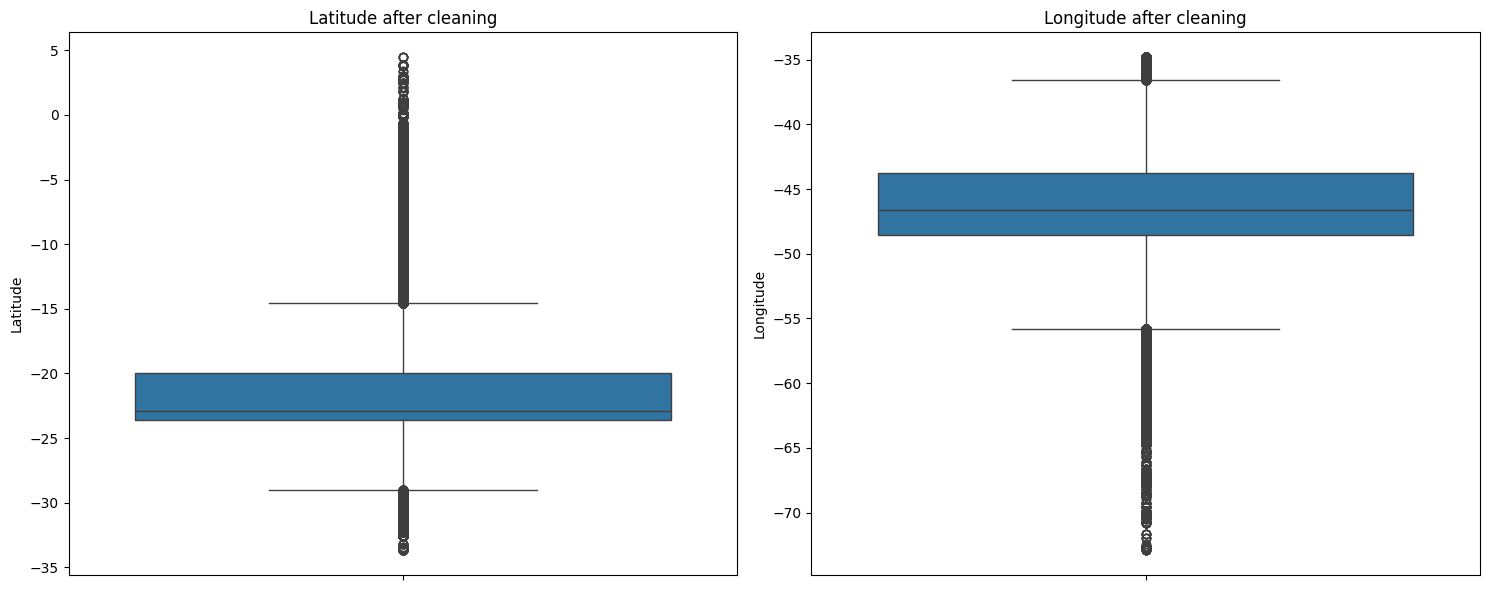

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Latitude boxplot on the first subplot
sns.boxplot(y=geolocation_df['geolocation_lat'], ax=axes[0])
axes[0].set_title('Latitude before cleaning')
axes[0].set_ylabel('Latitude')

# Plot Longitude boxplot on the second subplot
sns.boxplot(y=geolocation_df['geolocation_lng'], ax=axes[1])
axes[1].set_title('Longitude before cleaning')
axes[1].set_ylabel('Longitude')

plt.tight_layout()
plt.show()


# Removing extreme northern/southern outliers
geolocation_df = geolocation_df[
    (geolocation_df.geolocation_lat >= -33.75) & 
    (geolocation_df.geolocation_lat <= 5.27) &
    (geolocation_df.geolocation_lng >= -73.99) &
    (geolocation_df.geolocation_lng <= -34.79)
]



fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Latitude boxplot on the first subplot
sns.boxplot(y=geolocation_df['geolocation_lat'], ax=axes[0])
axes[0].set_title('Latitude after cleaning')
axes[0].set_ylabel('Latitude')

# Plot Longitude boxplot on the second subplot
sns.boxplot(y=geolocation_df['geolocation_lng'], ax=axes[1])
axes[1].set_title('Longitude after cleaning')
axes[1].set_ylabel('Longitude')

plt.tight_layout()
plt.show()

In [10]:
# Aggregating all features into one row per order_id
payments_summary = payments_df.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    dominant_payment_type=('payment_type', lambda x: x.mode()[0]),
    max_payment_installments=('payment_installments', 'max')
).reset_index()

# View the result
payments_df=payments_summary.copy()
reviews_df = reviews_df.groupby('order_id')['review_score'].mean().reset_index()

geo_lookup = geolocation_df.groupby('geolocation_zip_code_prefix').agg(
    latitude=('geolocation_lat', 'median'),
    longitude=('geolocation_lng', 'median')
).reset_index()

### Merge Chain

Merge order: `orders → customers → items → products → payments → reviews → geolocation`

All left joins from `orders_df` outward to preserve all delivered orders. The resulting dataframe is at **order-item grain** (one row per product per order), which expands from ~96K orders to ~110K rows due to multi-item orders.


In [11]:
merged_df = pd.merge(orders_df,customer_df,on = 'customer_id',how='left')
merged_df = pd.merge(merged_df,items_df,on='order_id',how='left')
merged_df = pd.merge(merged_df, products_df, on='product_id',how='left')
merged_df= pd.merge(merged_df, payments_df, on = 'order_id', how='left')
merged_df= pd.merge(merged_df, reviews_df, on = 'order_id', how='left')
merged_df = pd.merge(
    merged_df, 
    geo_lookup, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

display(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110173 entries, 0 to 110172
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110173 non-null  object        
 1   customer_id                    110173 non-null  object        
 2   order_status                   110173 non-null  object        
 3   order_purchase_timestamp       110173 non-null  datetime64[ns]
 4   order_approved_at              110173 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110173 non-null  datetime64[ns]
 6   order_delivered_customer_date  110173 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110173 non-null  datetime64[ns]
 8   customer_unique_id             110173 non-null  object        
 9   customer_zip_code_prefix       110173 non-null  int64         
 10  customer_city                  110173 non-null  object        
 11  

None

## Phase 3 — Customer-Level Aggregation

This is the critical transformation: collapsing the order-item dataframe into **one row per `customer_unique_id`**.

Note: `customer_unique_id` (not `customer_id`) is used because Olist assigns a new `customer_id` per order — the same person gets different IDs across purchases. `customer_unique_id` is the true person identifier.

**Features engineered:**
- **Monetary:** total spend, average order value, total freight
- **Frequency:** order count (nunique), total items purchased
- **Recency:** days since last purchase (reference = max date in dataset)
- **Product behavior:** unique categories, favourite category (mode), avg product weight
- **Payment behavior:** dominant payment type (mode), median installments
- **Satisfaction:** mean review score
- **Delivery experience:** mean shipping days (order to delivery)
- **Geography:** median latitude/longitude, state

In [12]:
#Recency
reference= merged_df.order_purchase_timestamp.max()
last_purchase = merged_df.groupby('customer_unique_id')['order_purchase_timestamp'].max()
latest_order= (reference - last_purchase).dt.days

#Delivery speed
merged_df['order_shipping_days'] = (merged_df.order_delivered_customer_date- merged_df.order_purchase_timestamp).dt.days


modified_df = merged_df.groupby('customer_unique_id').agg(
                    #Monetary:
                    total_price = ('price','sum'),
                    avg_order_value = ('price','mean'),
                    total_freight=('freight_value','sum'),
                    #Frequency:
                    order_count=('order_id','nunique'),
                    total_items = ('order_item_id', 'count'),
                    #product Behaviour
                    unique_categories = ('product_category_name_english','nunique'),
                    favourite_category = ('product_category_name_english',lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
                    avg_product_weight=('product_weight_g','mean'),
                    #payment Behaviour
                    dominant_payment_mode = ('dominant_payment_type',lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
                    avg_payment_installments = ('max_payment_installments','median'),
                    #Satisfaction:
                    avg_review_score = ('review_score','mean'),
                    #Delivery Experience
                    avg_shipping_days = ('order_shipping_days','mean'),
                    #Geography
                    latitude = ('latitude','median'),
                    longitude = ('longitude','median'),
                    state = ('customer_state',lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')                    
                    ).reset_index()
#Merging recency
modified_df = modified_df.merge(latest_order.rename('recency_days'), on='customer_unique_id')

#merging remaing modified columns
col=['avg_product_weight','avg_payment_installments','avg_review_score']
for i in col:
    modified_df[i] = modified_df[i].fillna(modified_df[i].median())

modified_df['latitude'] = modified_df['latitude'].fillna(
    modified_df.groupby('state')['latitude'].transform('median')
)

modified_df['longitude'] = modified_df['longitude'].fillna(
    modified_df.groupby('state')['longitude'].transform('median')
)

display(modified_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93336 entries, 0 to 93335
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_unique_id        93336 non-null  object 
 1   total_price               93336 non-null  float64
 2   avg_order_value           93336 non-null  float64
 3   total_freight             93336 non-null  float64
 4   order_count               93336 non-null  int64  
 5   total_items               93336 non-null  int64  
 6   unique_categories         93336 non-null  int64  
 7   favourite_category        93336 non-null  object 
 8   avg_product_weight        93336 non-null  float64
 9   dominant_payment_mode     93336 non-null  object 
 10  avg_payment_installments  93336 non-null  float64
 11  avg_review_score          93336 non-null  float64
 12  avg_shipping_days         93336 non-null  float64
 13  latitude                  93336 non-null  float64
 14  longit

None

## Phase 4 — Exploratory Data Analysis

Focused EDA on the customer-level dataframe to inform feature selection and transformation decisions for clustering.


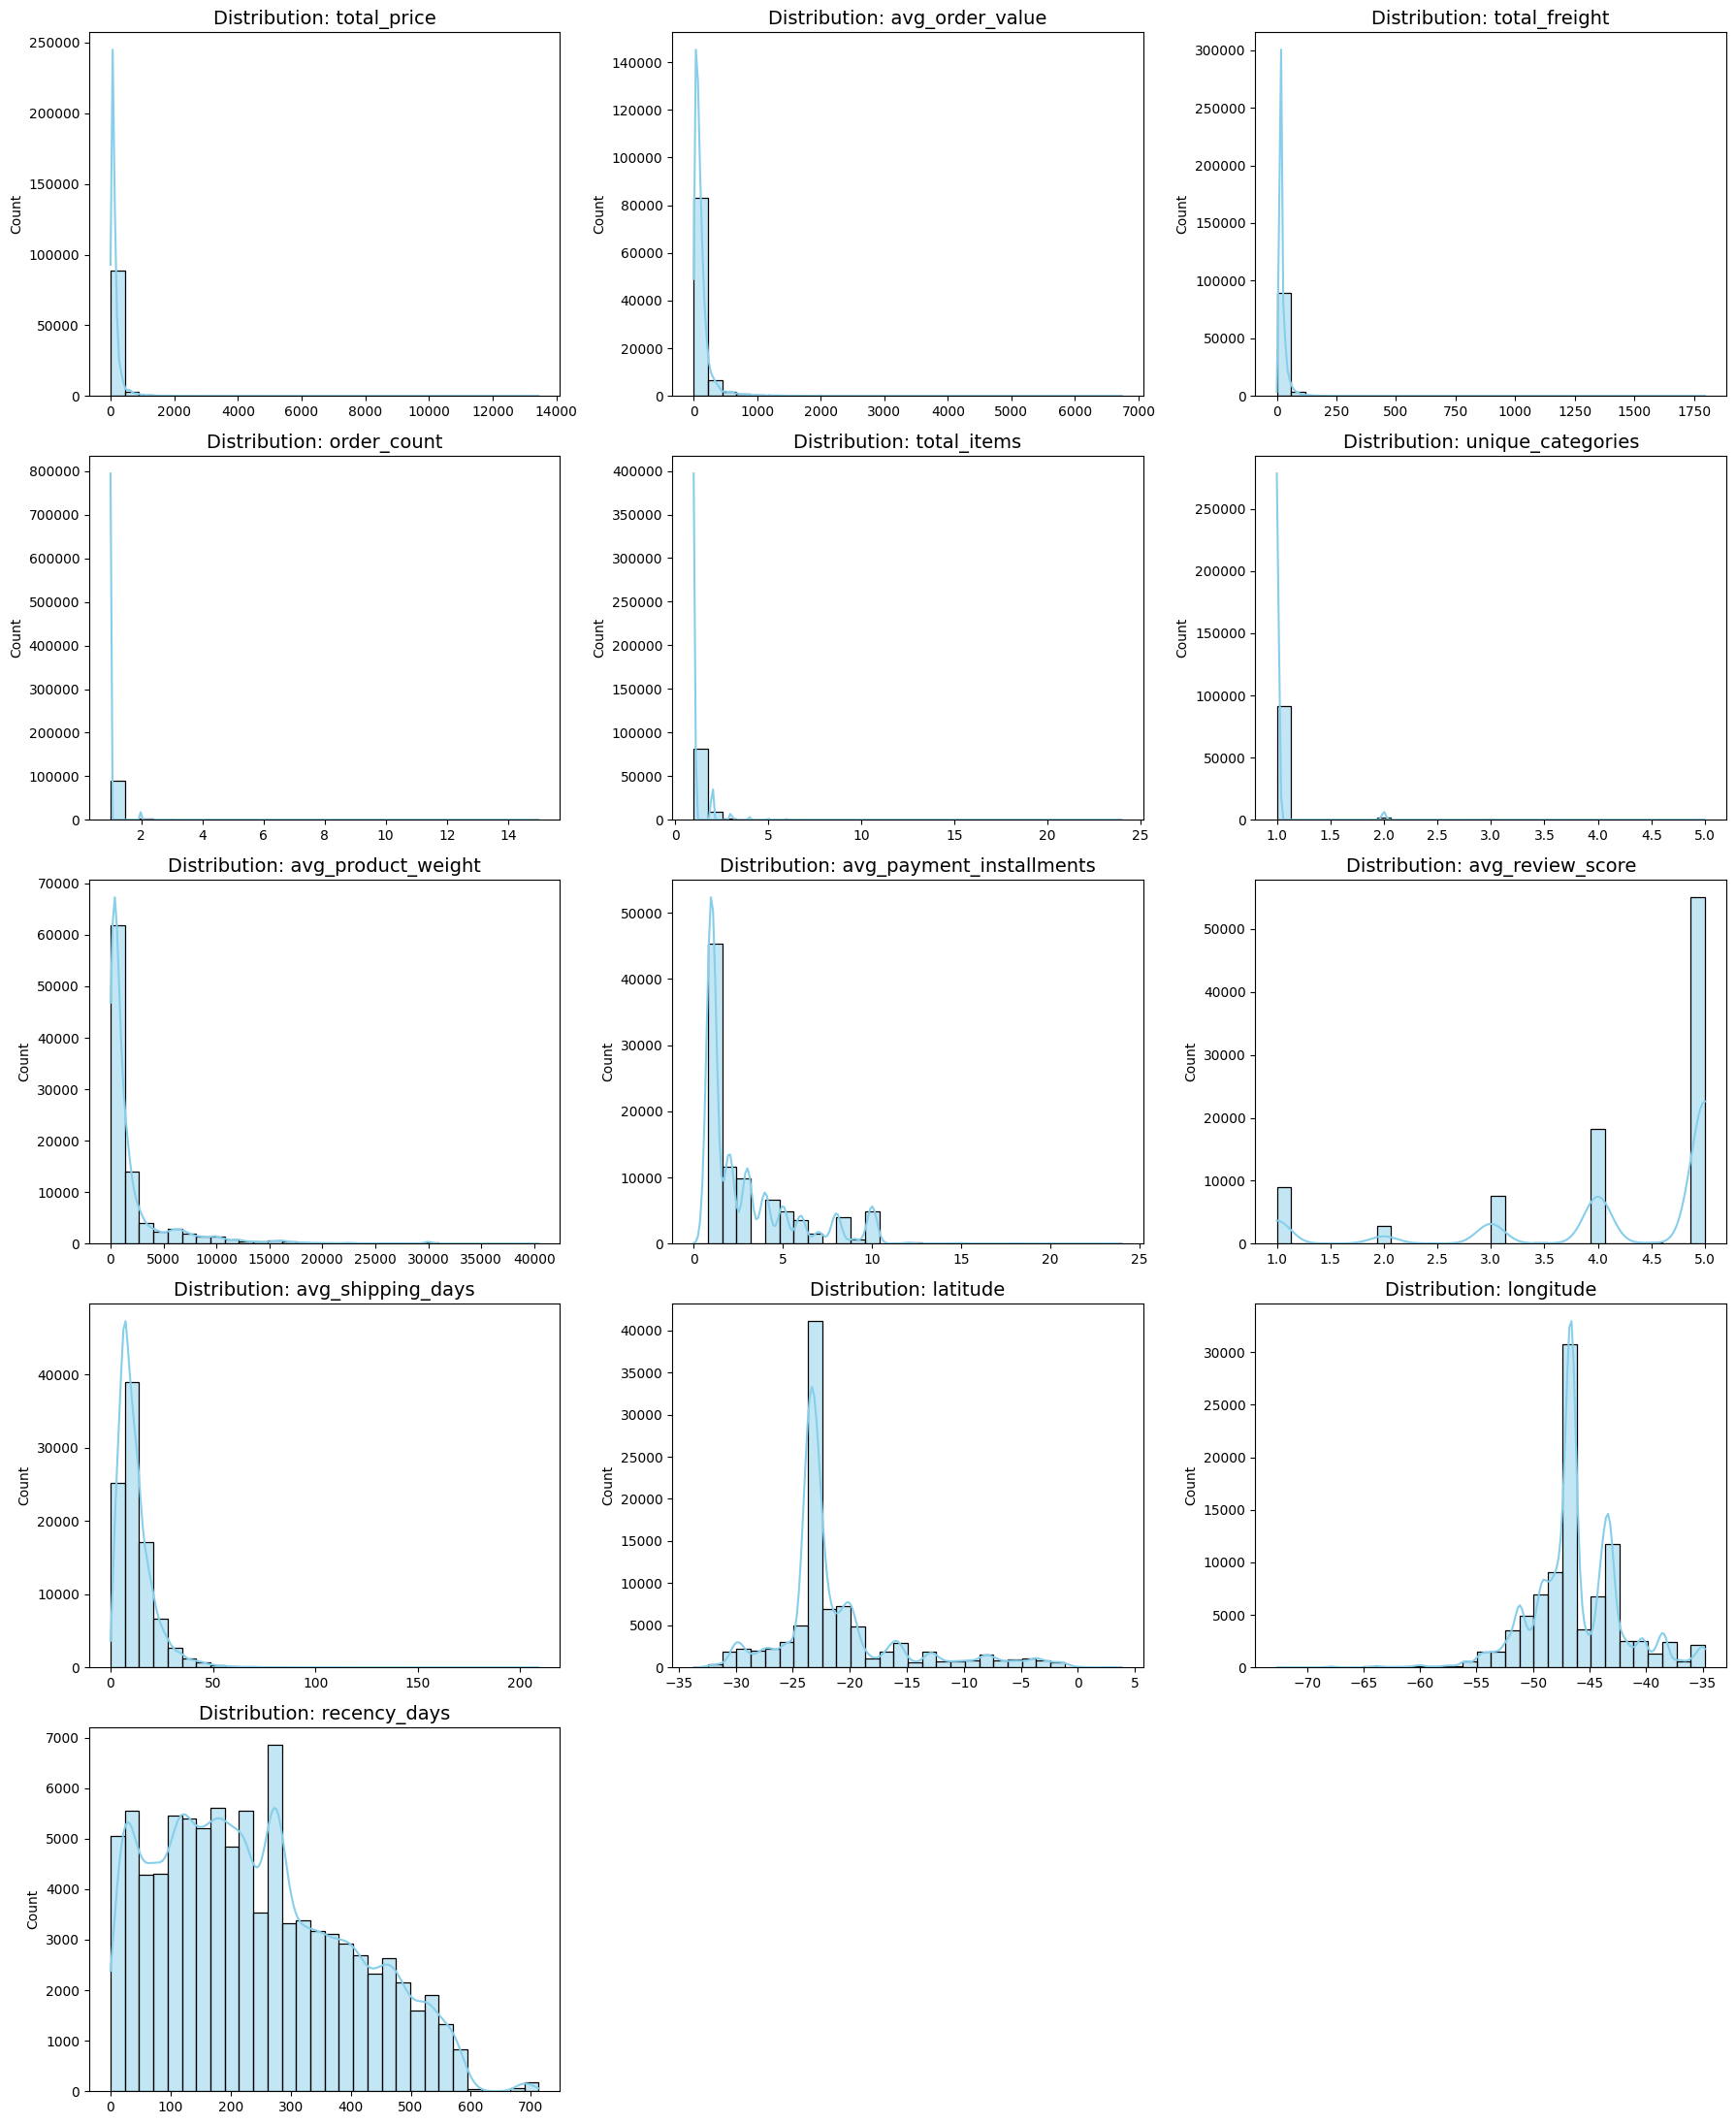

In [13]:
# Identify numeric columns
numeric_cols = modified_df.select_dtypes(include='number').columns

# Define the grid layout (5 rows, 3 columns for 13 features)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 22))
axes = axes.flatten()

# Loop through and plot each numeric feature
for i, col in enumerate(numeric_cols):
    sns.histplot(modified_df[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Remove the extra empty subplots (since 13 < 15)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### EDA Summary

**Skewness:** Monetary features (`total_price`, `total_freight`) and `avg_product_weight` are heavily right-skewed — most customers cluster at low values with a long tail of high spenders. Log transformation required before clustering.

**Near-zero variance:** `order_count`, `total_items`, and `unique_categories` show almost no variation — ~97% of customers have exactly 1 order with 1 item in 1 category. These features will be removed before clustering.

**Multicollinearity:** `total_price` and `avg_order_value` correlate at 0.92 — dropped `avg_order_value` to avoid double-weighting spending behavior.

**Business insight:** `avg_review_score` and `avg_shipping_days` correlate at -0.33 — slower deliveries are clearly associated with lower customer satisfaction, suggesting delivery optimization as a key lever.

**Dominance patterns:** Credit card accounts for ~75% of payments; São Paulo state accounts for ~40% of customers. Payment type is unlikely to differentiate clusters. Geographic features will capture regional variation.

**Recency:** Roughly uniform distribution across 0–700 days, providing good spread for clustering — no single recency band dominates.


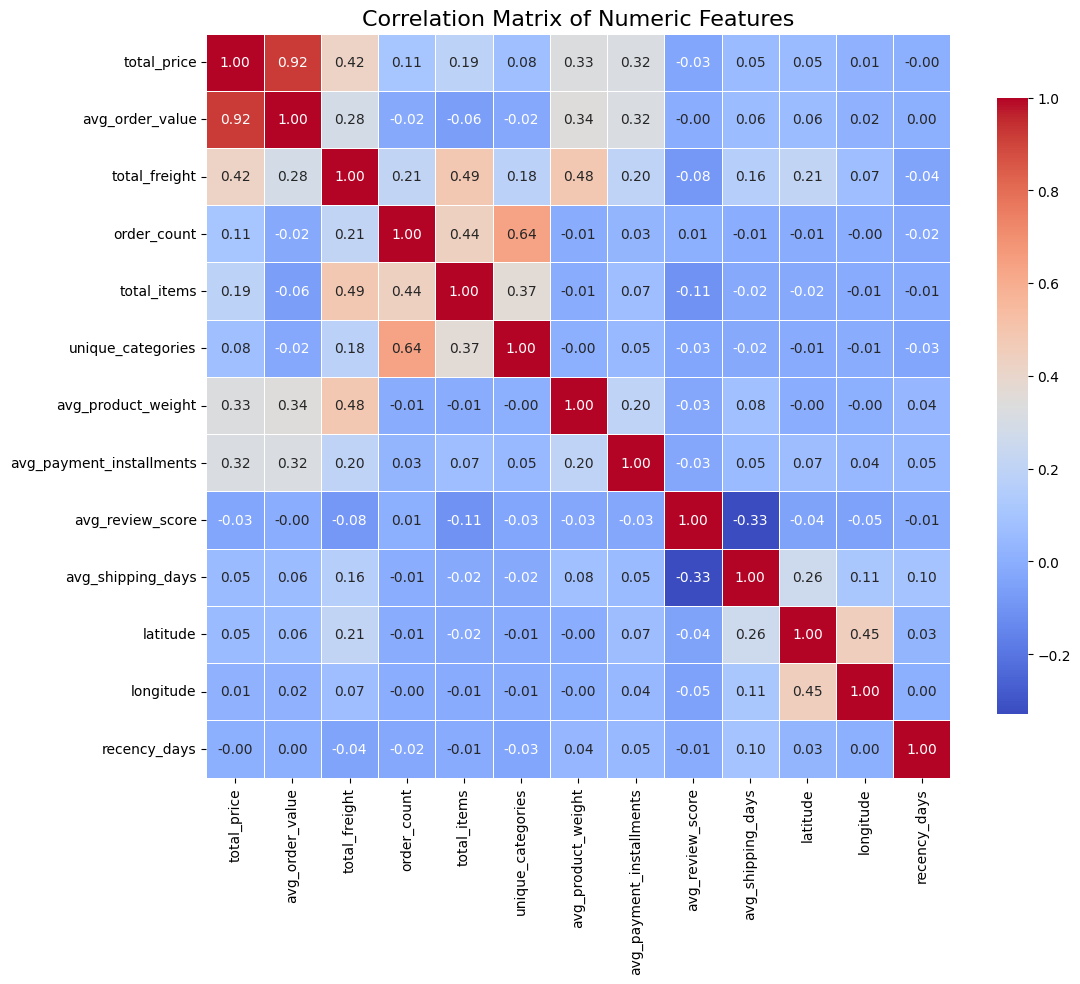

In [14]:
# Calculate the correlation matrix for numeric columns
corr_matrix = modified_df.select_dtypes(include='number').corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,          # Show values in cells
            fmt=".2f",           # Format to 2 decimal places
            cmap='coolwarm',     # Color map (red = positive, blue = negative)
            square=True,         # Make cells square
            linewidths=0.5,      # Add lines between cells
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

In [15]:
modified_df.drop('avg_order_value',axis = 1, inplace = True)

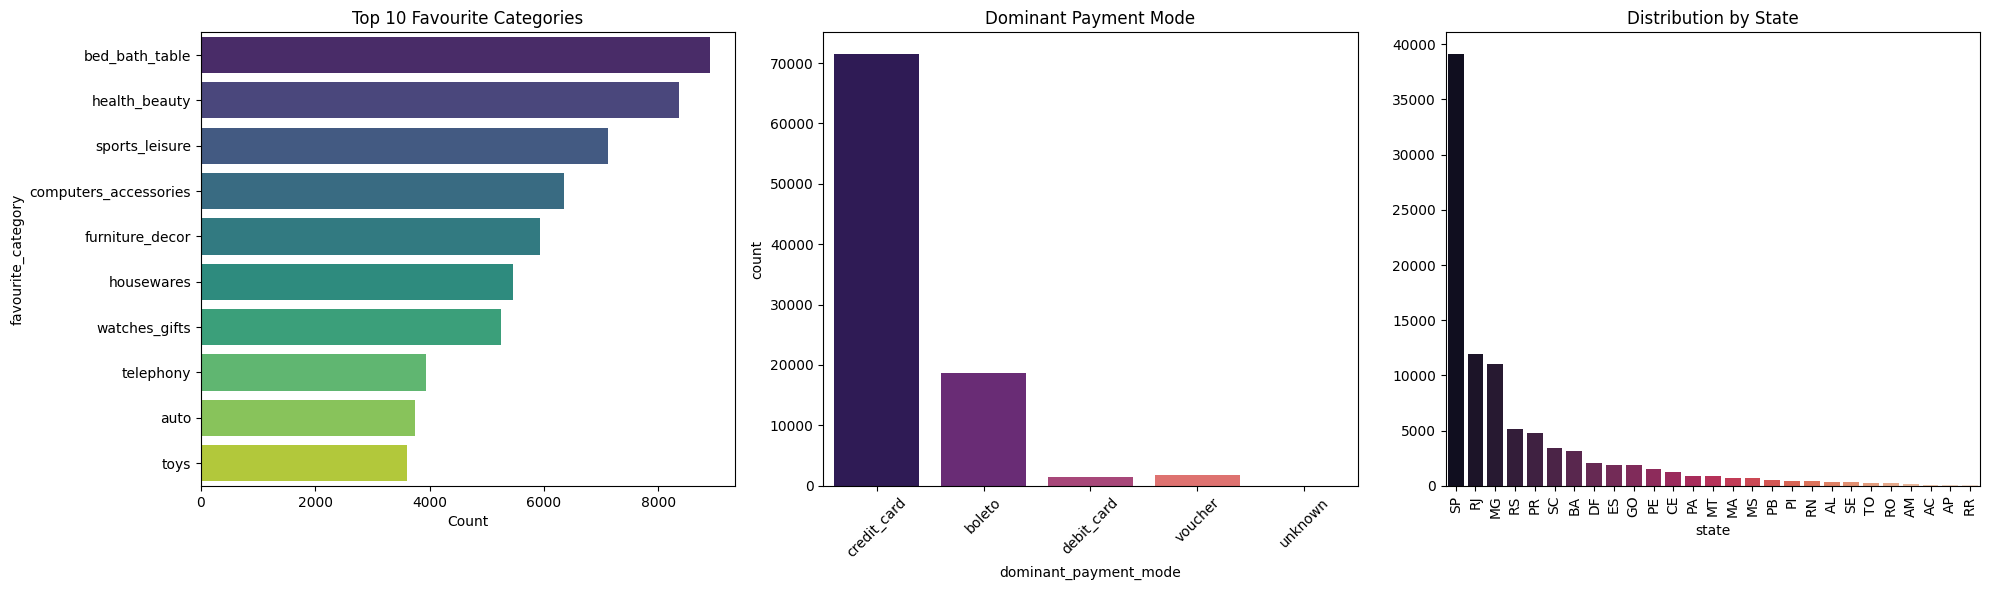

In [16]:
# Create a figure with three subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# 1. Top 10 Favourite Categories
top_10_cats = modified_df['favourite_category'].value_counts().head(10)
sns.barplot(x=top_10_cats.values, y=top_10_cats.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Favourite Categories')
axes[0].set_xlabel('Count')

# 2. Dominant Payment Mode
sns.countplot(data=modified_df, x='dominant_payment_mode', ax=axes[1], palette='magma')
axes[1].set_title('Dominant Payment Mode')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# 3. Orders by State
state_counts = modified_df['state'].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values, ax=axes[2], palette='rocket')
axes[2].set_title('Distribution by State')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

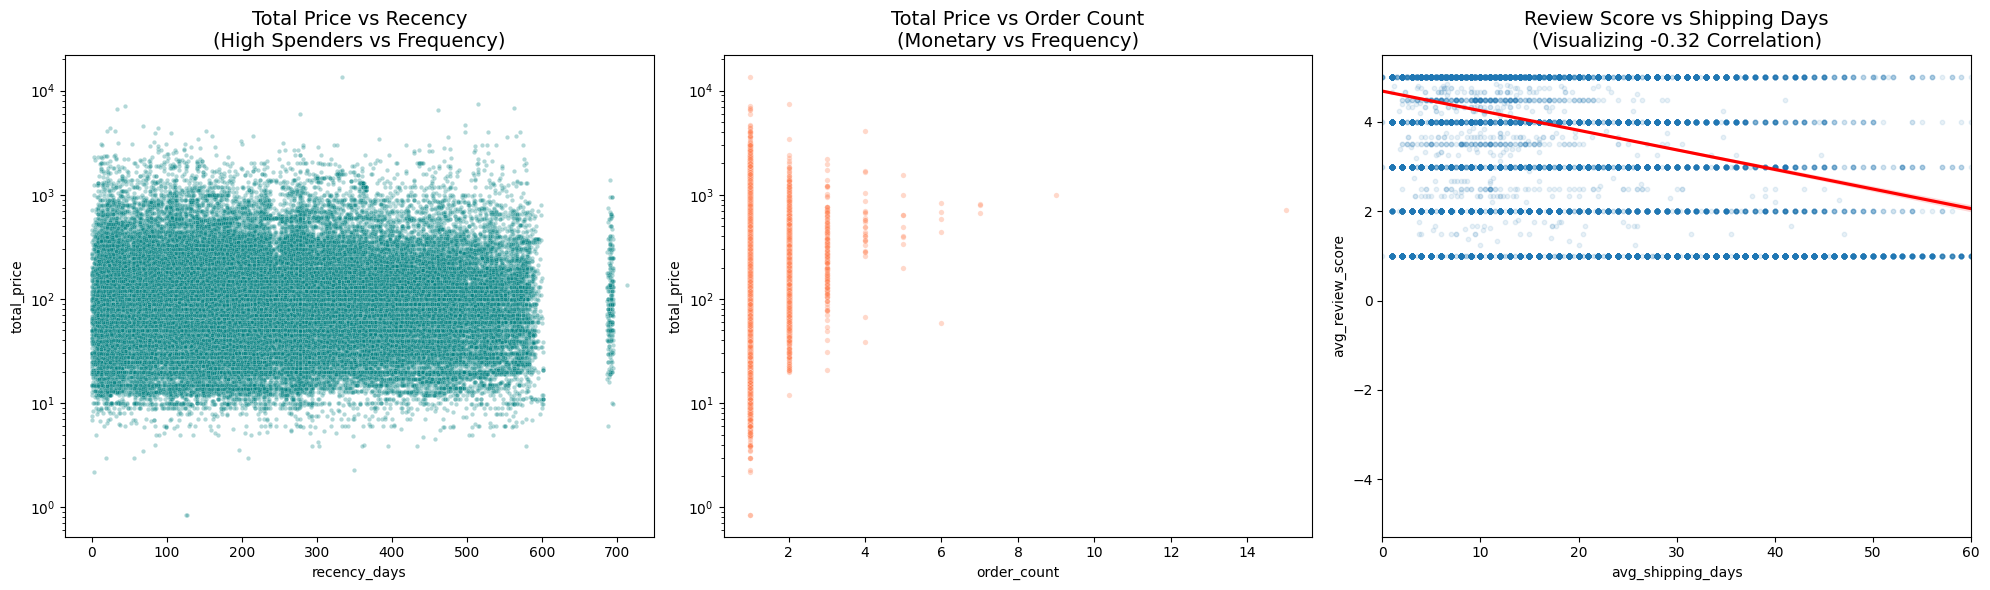

In [17]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Total Price vs Recency (Spending vs Time)
sns.scatterplot(data=modified_df, x='recency_days', y='total_price', 
                ax=axes[0], alpha=0.3, s=10, color='teal')
axes[0].set_title('Total Price vs Recency\n(High Spenders vs Frequency)', fontsize=14)
axes[0].set_yscale('log') # Use log scale if price has extreme outliers

# 2. Total Price vs Order Count (Spending vs Frequency)
sns.scatterplot(data=modified_df, x='order_count', y='total_price', 
                ax=axes[1], alpha=0.3, s=15, color='coral')
axes[1].set_title('Total Price vs Order Count\n(Monetary vs Frequency)', fontsize=14)
axes[1].set_yscale('log')

# 3. Review Score vs Shipping Days (The -0.32 Correlation)
# Using regplot to visualize the negative trend
sns.regplot(data=modified_df, x='avg_shipping_days', y='avg_review_score', 
            ax=axes[2], scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'red'})
axes[2].set_title('Review Score vs Shipping Days\n(Visualizing -0.32 Correlation)', fontsize=14)
axes[2].set_xlim(0, 60) # Capping x-axis for better visibility of the bulk of data

plt.tight_layout()
plt.show()

## Phase 5 — Feature Scaling & Preparation

**Steps:**
1. Select numeric features only (exclude identifiers and categorical columns reserved for post-clustering profiling)
2. Log-transform right-skewed features: `total_price`, `total_freight`, `avg_product_weight`, `avg_shipping_days`
3. StandardScaler to center all features at mean=0, std=1
4. Remove near-zero variance features: `order_count`, `total_items`, `unique_categories`

**Final clustering input:** 9 features × 93,336 customers

In [18]:
# Select only numeric columns for the clustering dataframe
# We exclude 'customer_unique_id' as it's an identifier, 
# and the categorical strings which we'll use later for profiling.

# Get all numeric columns first
numeric_df = modified_df.select_dtypes(include='number')

# Create the clustering-specific dataframe
# We drop any columns that might act as identifiers or are redundant
cluster_features = numeric_df.copy()

# Note: 'customer_unique_id' is likely your index or a non-numeric string, 
# but we ensure only pure features remain.
# If you have specific numeric IDs, drop them here:
# cluster_features = cluster_features.drop(columns=['some_numeric_id'], errors='ignore')

print(f"Shape of clustering dataframe: {cluster_features.shape}")
print("\nFeatures selected for clustering:")
print(cluster_features.columns.tolist())

Shape of clustering dataframe: (93336, 12)

Features selected for clustering:
['total_price', 'total_freight', 'order_count', 'total_items', 'unique_categories', 'avg_product_weight', 'avg_payment_installments', 'avg_review_score', 'avg_shipping_days', 'latitude', 'longitude', 'recency_days']


In [19]:
# List of columns to transform based on heavy right skew
cols_to_log = ['total_price', 'total_freight', 'avg_product_weight', 'avg_shipping_days']

# Apply log1p transformation
# np.log1p is safer than np.log as it handles zero values gracefully
cluster_features[cols_to_log] = cluster_features[cols_to_log].apply(np.log1p)

# Verify the transformation
print("Transformation complete.")
cluster_features[cols_to_log].head()

Transformation complete.


,total_price,total_freight,avg_product_weight,avg_shipping_days
0,4.874434,2.564949,7.313887,1.945910
1,2.990720,2.228939,5.929589,1.386294
2,4.248495,2.902520,7.313887,3.258097
3,3.295466,2.924773,5.017280,3.044522
4,5.198497,2.884242,8.707979,2.639057


In [20]:

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
# We keep the column names and index for easy re-attachment later
scaled_features_array = scaler.fit_transform(cluster_features)

# Create a new DataFrame with the scaled data
cluster_features_scaled = pd.DataFrame(
    scaled_features_array, 
    columns=cluster_features.columns, 
    index=cluster_features.index
)

# Store the scaler object (it's already stored in the 'scaler' variable)
# You'll need this later to run scaler.inverse_transform() to see the real values 
# for each cluster's centroids.

print("Scaling complete. Each feature now has mean ≈ 0 and std ≈ 1.")
cluster_features_scaled.head()

Scaling complete. Each feature now has mean ≈ 0 and std ≈ 1.


,total_price,total_freight,order_count,total_items,unique_categories,avg_product_weight,avg_payment_installments,avg_review_score,avg_shipping_days,latitude,longitude,recency_days
0,0.420901,-0.778739,-0.159816,-0.290527,-0.15171,0.460404,1.884742,0.658092,-0.669197,-0.384637,-0.157416,-0.825317
1,-1.618856,-1.367868,-0.159816,-0.290527,-0.15171,-0.583025,-0.711245,-0.124184,-1.549036,-0.423918,-0.148042,-0.805651
2,-0.256889,-0.186876,-0.159816,-0.290527,-0.15171,0.460404,1.884742,-0.906459,1.393848,-1.134949,-0.602896,1.960616
3,-1.288865,-0.147859,-0.159816,-0.290527,-0.15171,-1.270688,0.401321,-0.124184,1.058063,3.545198,-0.566105,0.544707
4,0.771809,-0.218923,-0.159816,-0.290527,-0.15171,1.511215,1.143031,0.658092,0.420583,-0.414689,-0.316271,0.328387


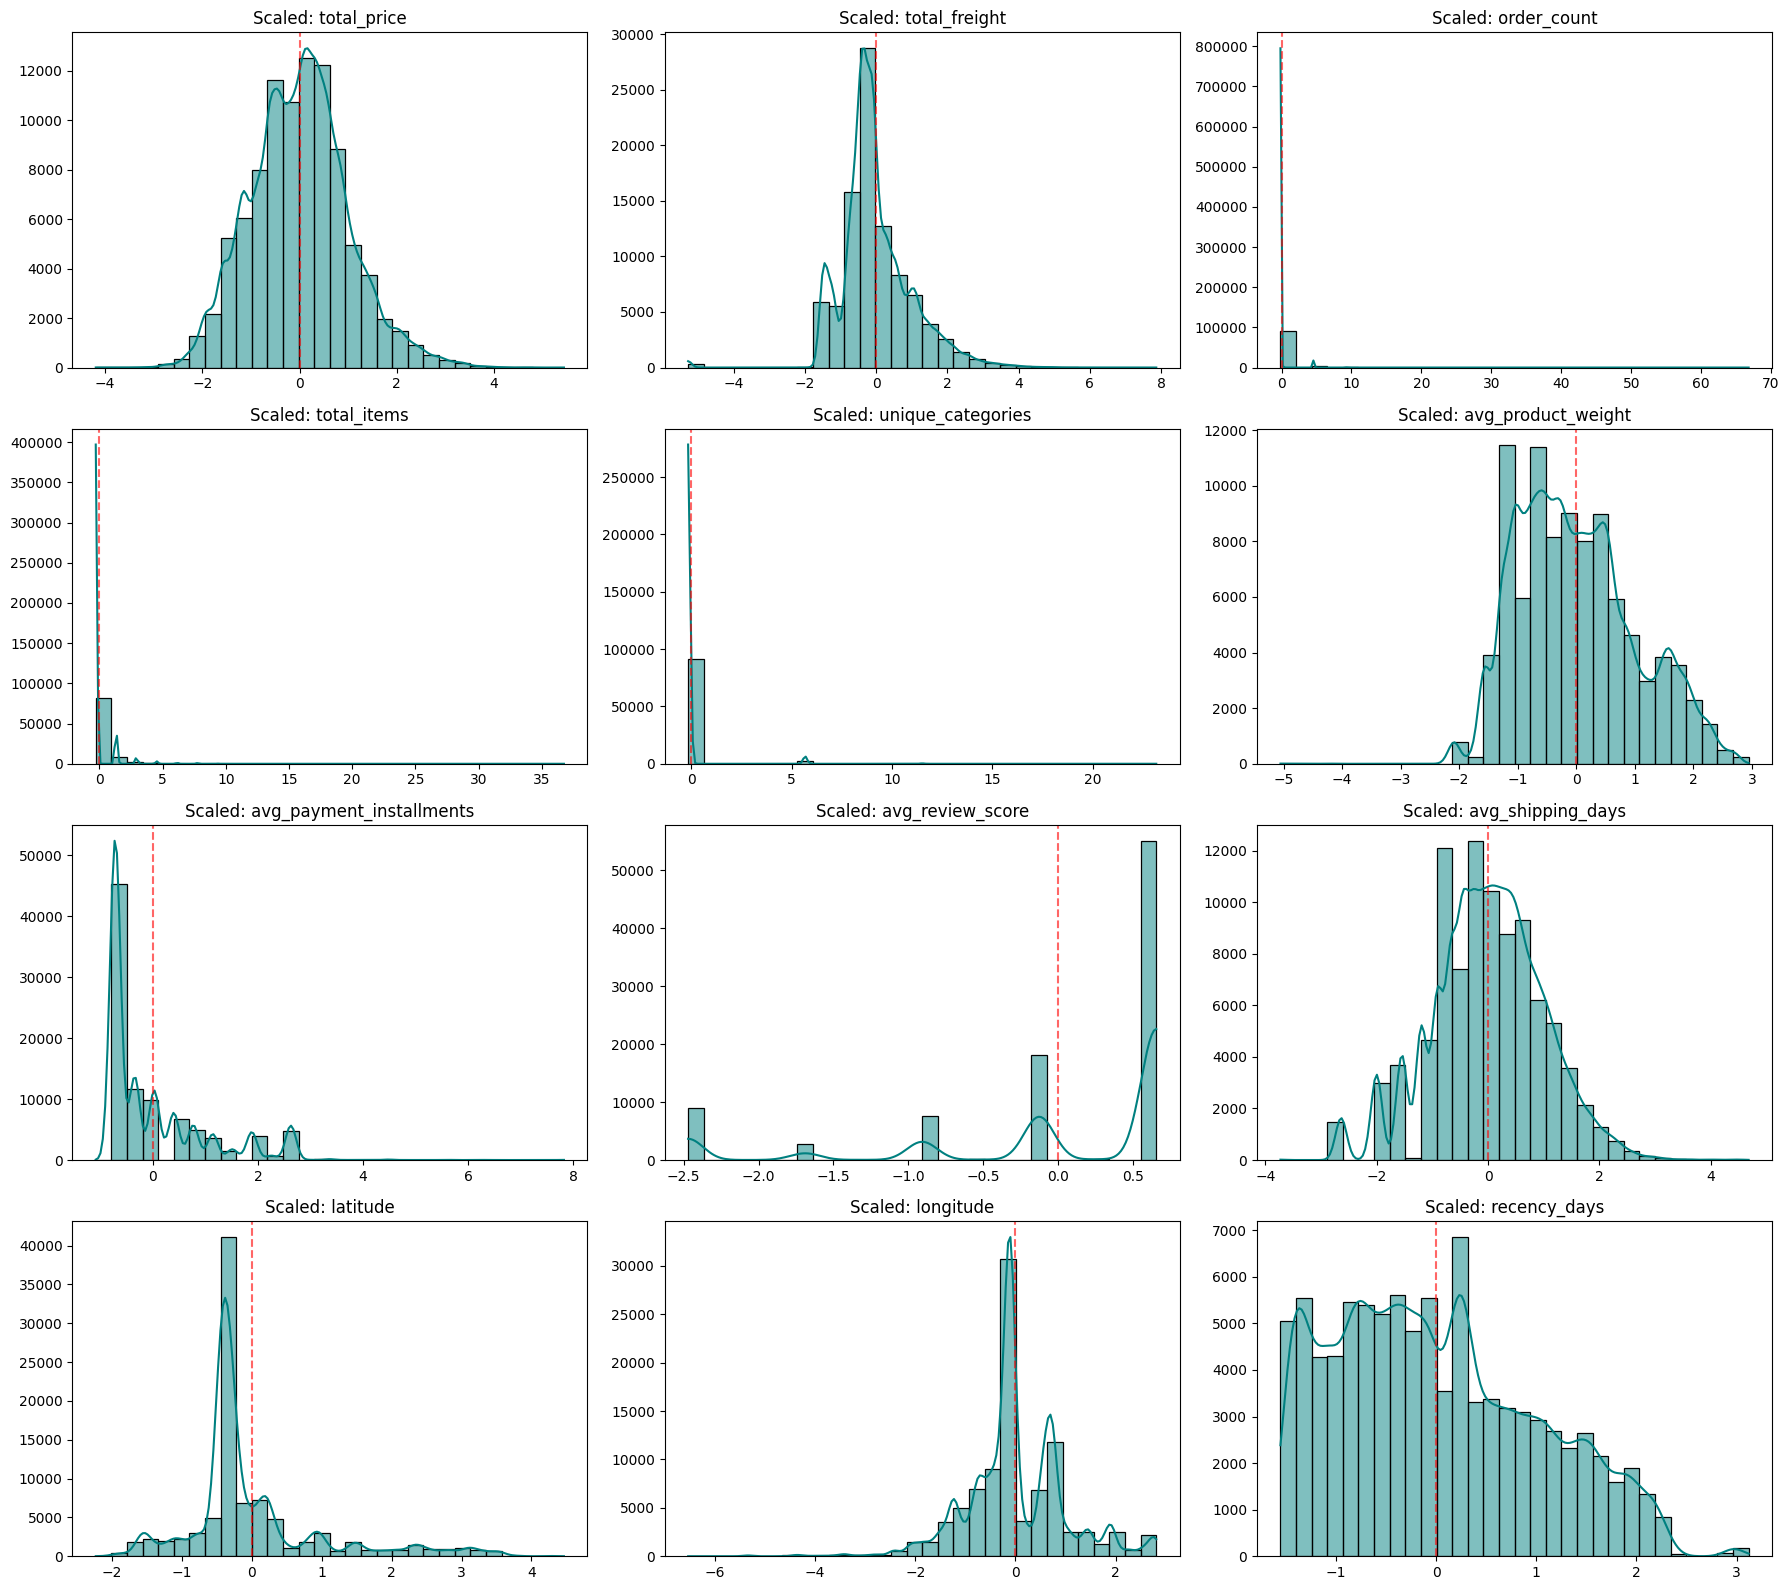

In [21]:
# Define the grid (4 rows, 3 columns for 12 features)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

# Loop through the scaled columns
for i, col in enumerate(cluster_features_scaled.columns):
    sns.histplot(cluster_features_scaled[col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Add a vertical line at 0 to confirm centering
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.6)
    
    axes[i].set_title(f'Scaled: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Clean up empty space
plt.tight_layout()
plt.show()

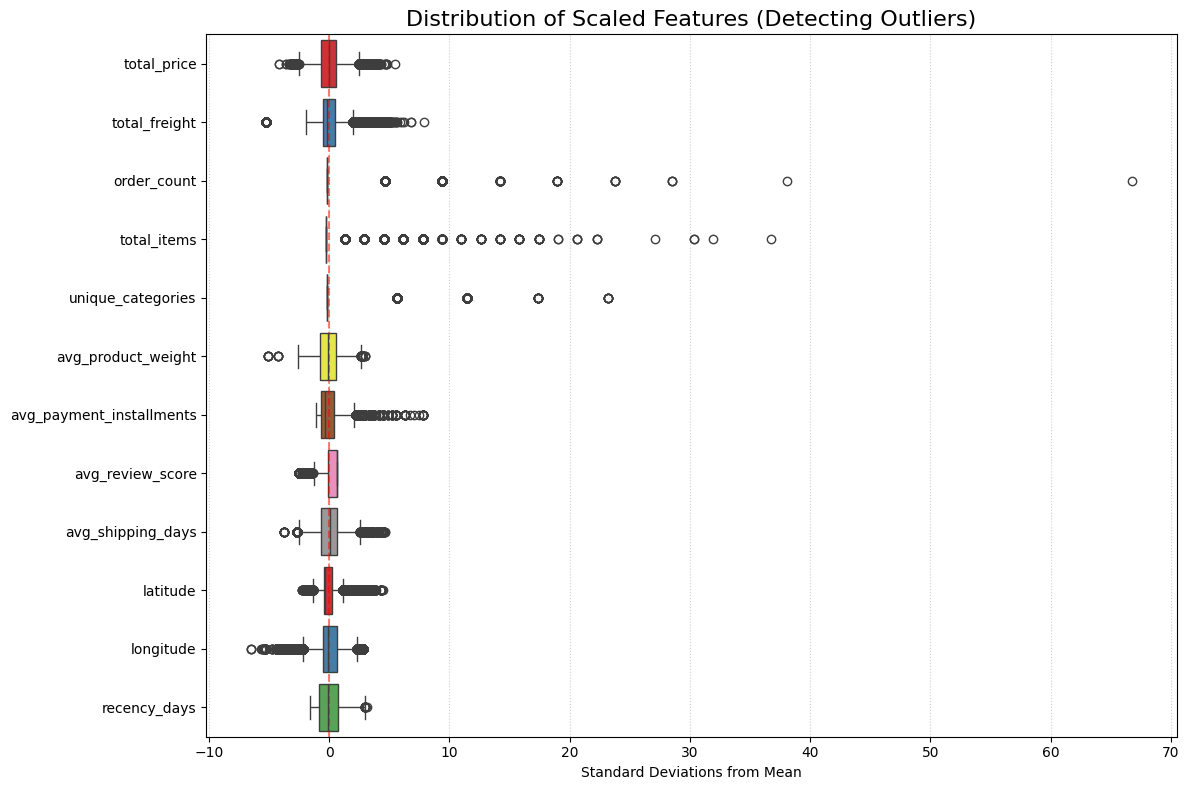

In [23]:

# Set figure size for 12 features
plt.figure(figsize=(12, 8))


sns.boxplot(data=cluster_features_scaled, orient='h', palette='Set1')

# Add a vertical line at 0 (the mean)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.title('Distribution of Scaled Features (Detecting Outliers)', fontsize=16)
plt.xlabel('Standard Deviations from Mean')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
cluster_features_scaled.drop(['order_count', 'total_items', 'unique_categories'], axis = 1, inplace = True)

## Phase 6 — Clustering

### 6.1 K-Means

Using elbow method (inertia) and silhouette scores to determine optimal k.

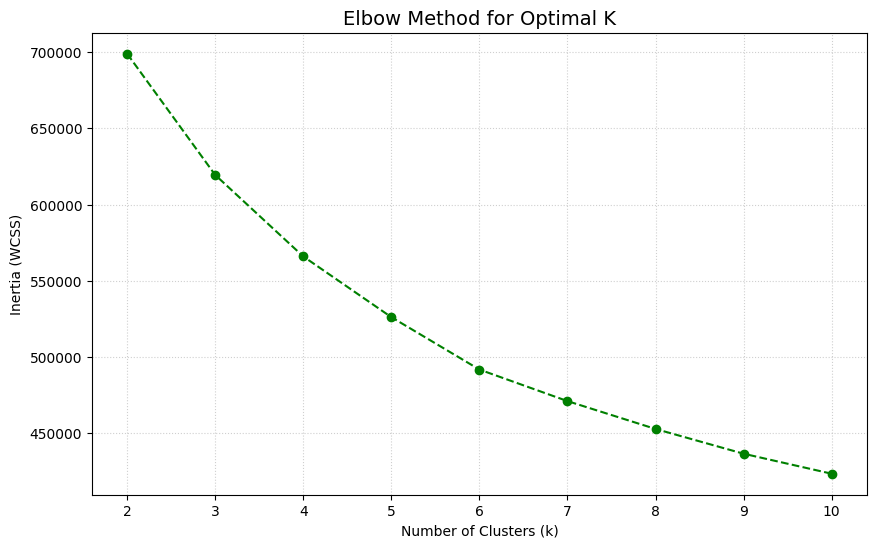

In [25]:

# Initialize an empty list to store inertia values
inertia = []
k_range = range(2, 11)

# Run K-Means for k=2 through k=10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='green')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)

# Annotate the potential elbow point (visual guide)
plt.show()

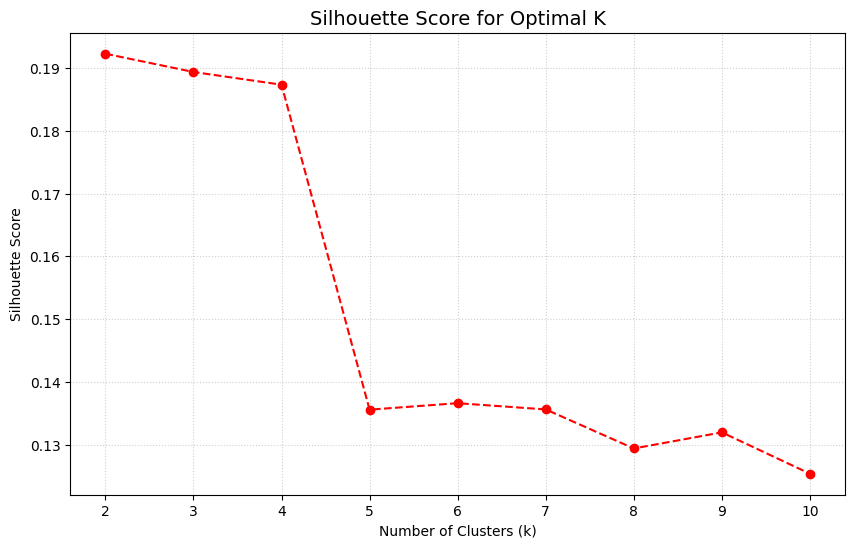

In [26]:


sample_idx = np.random.choice(len(cluster_features_scaled), size=10000, replace=False)

sample_data = cluster_features_scaled.iloc[sample_idx] 

sil_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fix 2: Fit and predict on the SAMPLE data so labels match the sample size
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    sil_scores.append(score)


# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_scores, marker='o', linestyle='--', color='red')
plt.title('Silhouette Score for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Elbow** suggests k=4–5 (diminishing returns after). **Silhouette** peaks at k=2–4, with a sharp drop after k=4.

Selected **k=4** — balances statistical fit with business interpretability. Silhouette scores are modest (0.12–0.19), which is typical for real-world customer data where behavior exists on a spectrum rather than in discrete clusters.


In [27]:

# 1. Initialize and fit the final model with 4 clusters
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

# We fit on the SCALED data so the distances are mathematically sound
cluster_labels = kmeans_final.fit_predict(cluster_features_scaled)

# 2. Add labels back to the ORIGINAL modified_df for profiling
modified_df['cluster'] = cluster_labels

# 3. Quick check of the cluster sizes
print("Customer counts per cluster:")
print(modified_df['cluster'].value_counts())

# 4. Preview the first few rows with their new labels
modified_df[['customer_unique_id', 'total_price', 'recency_days', 'cluster']].head()

Customer counts per cluster:
cluster
0    44209
2    27081
3    12273
1     9773
Name: count, dtype: int64


,customer_unique_id,total_price,recency_days,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,111,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,114,0
2,0000f46a3911fa3c0805444483337064,69.00,536,3
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,320,1
4,0004aac84e0df4da2b147fca70cf8255,180.00,287,2


### 6.2 Hierarchical Clustering (Validation)

Using Ward's method on a 5K sample for dendrogram visualization, and AgglomerativeClustering on a 20K sample for label comparison with K-Means.

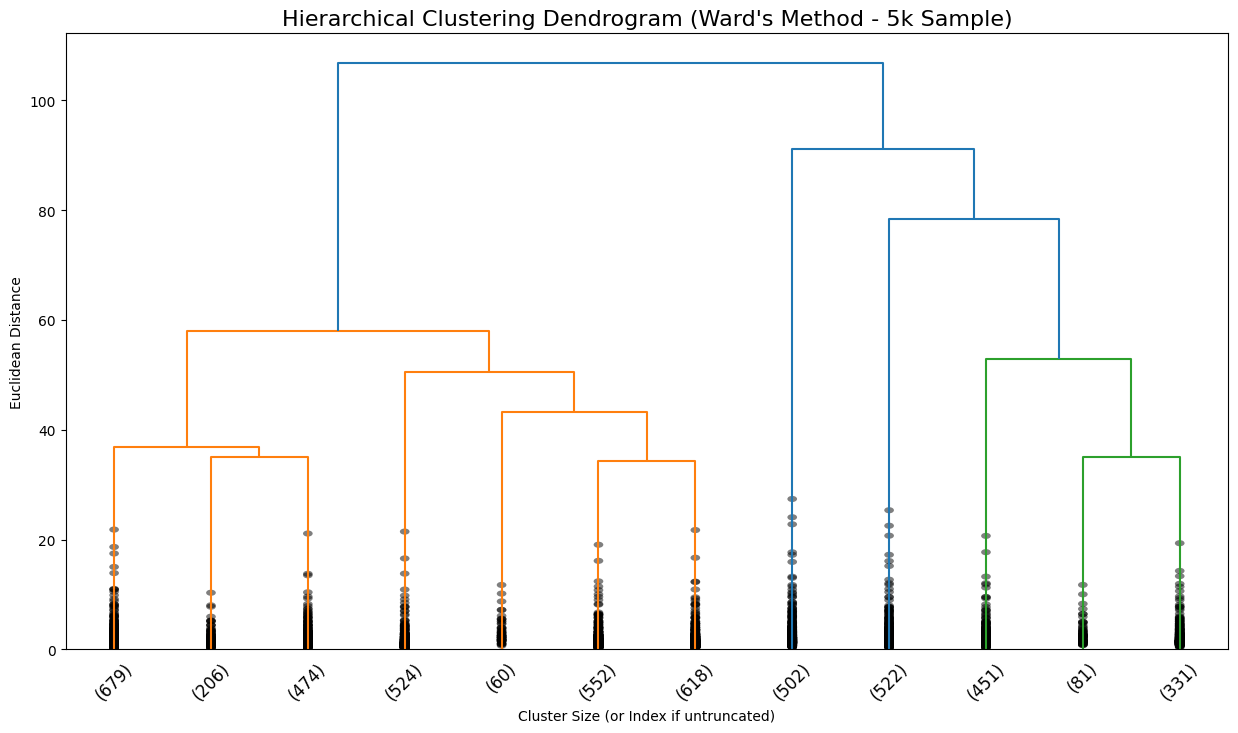

In [28]:

# 1. Take a random sample of 5,000 points for visualization
np.random.seed(42)
sample_idx = np.random.choice(cluster_features_scaled.index, size=5000, replace=False)
sample_data = cluster_features_scaled.loc[sample_idx]

# 2. Perform Hierarchical Clustering using Ward's Method
Z = sch.linkage(sample_data, method='ward')

# 3. Plot the Dendrogram
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(
    Z, 
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=12,                   # Show 12 leaf nodes for clarity
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True    # Visually indicate how many points are in truncated branches
)

# Add a horizontal line at the distance that would give us 4 clusters
# This visualizes why we chose k=4
plt.axhline(y=150, color='r', linestyle='--') 

plt.title('Hierarchical Clustering Dendrogram (Ward\'s Method - 5k Sample)', fontsize=16)
plt.xlabel('Cluster Size (or Index if untruncated)')
plt.ylabel('Euclidean Distance')
plt.show()

In [29]:

# 1. Take a sample that fits in memory (20k is usually the safe limit for 16GB RAM)
sample_size = 20000 
indices = np.random.choice(cluster_features_scaled.index, size=sample_size, replace=False)
sample_features = cluster_features_scaled.loc[indices]

# 2. Initialize and fit on the SAMPLE
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
sample_labels = agg_clustering.fit_predict(sample_features)

# 3. To compare with K-Means, we look at the overlap on this specific sample
comparison_df = modified_df.loc[indices].copy()
comparison_df['cluster_hierarchical'] = sample_labels

print("Hierarchical Cluster Counts (on 20k sample):")
print(comparison_df['cluster_hierarchical'].value_counts().sort_index())

# 4. Check alignment with K-Means
print("\nCross-tabulation (K-Means vs Hierarchical):")
print(pd.crosstab(comparison_df['cluster'], comparison_df['cluster_hierarchical']))

Hierarchical Cluster Counts (on 20k sample):
cluster_hierarchical
0    13248
1     2924
2     2052
3     1776
Name: count, dtype: int64

Cross-tabulation (K-Means vs Hierarchical):
cluster_hierarchical     0     1     2     3
cluster                                     
0                     9279    27    12    86
1                       91     5  1946     1
2                     3207  2632    41    81
3                      671   260    53  1608


**Cross-tabulation result:** K-Means clusters 0, 1, and 3 show near-perfect 1:1 mapping with hierarchical clusters — over 90% agreement. K-Means Cluster 2 splits across two hierarchical groups, suggesting a potential sub-segment that could be explored with k=5 if finer granularity is needed.

This strong alignment across two independent algorithms validates that the 4-cluster structure is a genuine property of the data, not an artifact of K-Means initialization.


### 6.3 DBSCAN (Density Check)

Using k-distance graph to determine epsilon, with min_samples=9 (matching feature dimensionality).

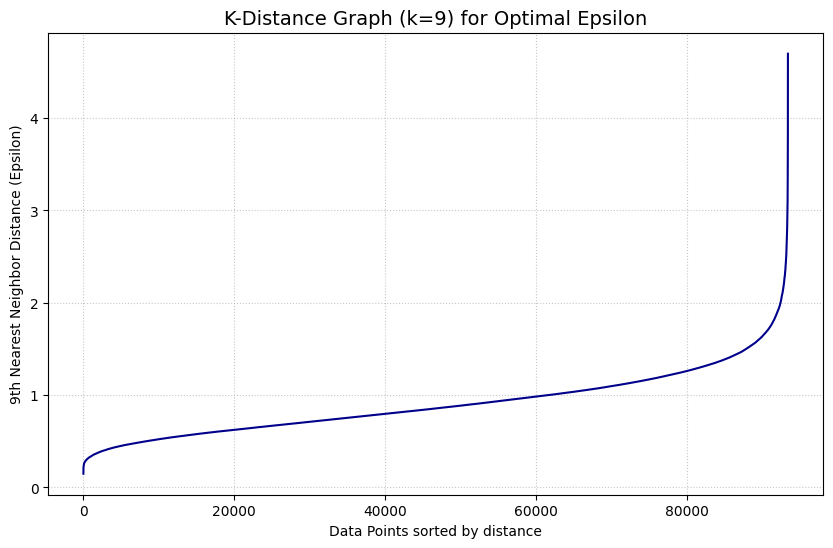

In [30]:


# 1. Compute distances to the 9th nearest neighbor
# n_neighbors=10 because the first neighbor is the point itself (distance 0)
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(cluster_features_scaled)
distances, indices = neighbors_fit.kneighbors(cluster_features_scaled)

# 2. Sort the distances (the 9th column contains distance to the 9th neighbor)
sorted_distances = np.sort(distances[:, 9], axis=0)

# 3. Plot the K-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, color='darkblue')
plt.title('K-Distance Graph (k=9) for Optimal Epsilon', fontsize=14)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('9th Nearest Neighbor Distance (Epsilon)')
plt.grid(True, linestyle=':', alpha=0.7)

# Add a zoom-in on the elbow area if needed
# plt.ylim(0, 2) 

plt.show()

## Clustering Algorithm Comparison

| Algorithm | Resulting Groups | Alignment & Suitability | Key Takeaway |
|-----------|-----------------|------------------------|--------------|
| **K-Means** | 4 Clusters | Balanced & distinct across features. | **Best for Actionable Segmentation.** Effectively split customers by spend, geography, and satisfaction. |
| **Hierarchical** | 4 Clusters | 90%+ agreement with K-Means labels. | **Structural Validation.** Confirms the 4-cluster structure is a property of the data, not an algorithm artifact. |
| **DBSCAN** | 1 Giant Cluster + Noise | Low granularity (91.5% in one group). | **Outlier Detection.** Excellent for identifying "Noise" (extreme cases), but fails to segment the dense core. |

**Final Model:** K-Means (k=4) selected as the primary segmentation model based on balanced cluster sizes, interpretable profiles, and cross-validation with hierarchical clustering.



### Detailed Breakdown

**K-Means (k=4):** This method provided the most balanced distribution. The profile table shows distinct personas — a high-freight North/Northeast group, a high-spending premium segment, a satisfied casual buyer base, and a dissatisfied group with delivery issues.

**Hierarchical (Ward):** The cross-tabulation shows that K-Means clusters 0, 1, and 3 have nearly 1:1 mapping with Hierarchical groups. The split in K-Means Cluster 2 suggests it could potentially be broken into two smaller sub-segments if more granular marketing strategies were needed.

**DBSCAN (eps=1.2):** With 91.5% of customers in one cluster, this confirms the data is a continuous distribution. Most customers behave similarly with only gradual variations, rather than forming dense, isolated islands of behavior.

### Final Recommendation

> DBSCAN identified one dominant cluster with several small outlier groups, confirming that customer behavior in this dataset forms a continuous distribution rather than density-separated clusters. K-Means with k=4 provides the most actionable segmentation for business strategy and targeted marketing.

In [31]:

# 1. Initialize and fit DBSCAN
# eps=1.2 is our starting point from the elbow plot
dbscan = DBSCAN(eps=1.2, min_samples=9)
dbscan_labels = dbscan.fit_predict(cluster_features_scaled)

# 2. Add to modified_df for analysis
modified_df['cluster_dbscan'] = dbscan_labels

# 3. Check results
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_} (out of {len(modified_df)})")
print(f"Percentage of noise: {(n_noise_ / len(modified_df)) * 100:.2f}%")

# 4. Distribution of points across clusters
print("\nPoints per DBSCAN cluster:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

Estimated number of clusters: 12
Estimated number of noise points: 7529 (out of 93336)
Percentage of noise: 8.07%

Points per DBSCAN cluster:
-1      7529
 0     85464
 1       220
 2        30
 3         9
 4        22
 5        17
 6         9
 7         7
 8         8
 9         6
 10        8
 11        7
Name: count, dtype: int64


## Clustering Algorithm Comparison

| Algorithm | Resulting Groups | Alignment & Suitability | Key Takeaway |
|-----------|-----------------|------------------------|--------------|
| **K-Means** | 4 Clusters | Balanced & distinct across features. | **Best for Actionable Segmentation.** Effectively split customers by spend, geography, and satisfaction. |
| **Hierarchical** | 4 Clusters | 90%+ agreement with K-Means labels. | **Structural Validation.** Confirms the 4-cluster structure is a property of the data, not an algorithm artifact. |
| **DBSCAN** | 1 Giant Cluster + Noise | Low granularity (91.5% in one group). | **Outlier Detection.** Excellent for identifying "Noise" (extreme cases), but fails to segment the dense core. |

**Final Model:** K-Means (k=4) selected as the primary segmentation model based on balanced cluster sizes, interpretable profiles, and cross-validation with hierarchical clustering.



### Detailed Breakdown

**K-Means (k=4):** This method provided the most balanced distribution. The profile table shows distinct personas — a high-freight North/Northeast group, a high-spending premium segment, a satisfied casual buyer base, and a dissatisfied group with delivery issues.

**Hierarchical (Ward):** The cross-tabulation shows that K-Means clusters 0, 1, and 3 have nearly 1:1 mapping with Hierarchical groups. The split in K-Means Cluster 2 suggests it could potentially be broken into two smaller sub-segments if more granular marketing strategies were needed.

**DBSCAN (eps=1.2):** With 91.5% of customers in one cluster, this confirms the data is a continuous distribution. Most customers behave similarly with only gradual variations, rather than forming dense, isolated islands of behavior.

### Final Recommendation

> DBSCAN identified one dominant cluster with several small outlier groups, confirming that customer behavior in this dataset forms a continuous distribution rather than density-separated clusters. K-Means with k=4 provides the most actionable segmentation for business strategy and targeted marketing.

## Phase 7 — Cluster Profiling & Business Recommendations

## Customer Segment Profiles

### Cluster 0 — "Budget Casuals" (44,209 customers / 47%)

The largest group. Low spend (R$67), lightest products (659g), fewest installments (1.8), fastest delivery (9 days), and highest satisfaction (4.65). These are one-time buyers picking up small, inexpensive items with quick delivery. They're happy but not deeply engaged.

**Strategy:** Upsell and cross-sell. They had a good experience — send targeted recommendations for complementary products. Low-cost loyalty nudges (free shipping on second order) could convert them to repeat buyers.

---

### Cluster 1 — "Remote Regionals" (9,773 customers / 10%)

Located in Brazil's Northeast (lat -8, lng -40). Moderate spend (R$168), heaviest average products after Cluster 2 (2,027g), longest shipping (20 days), and middling satisfaction (4.04). Geography is the defining trait — these customers are far from the Southeast logistics hubs.

**Strategy:** Logistics optimization. Partner with regional carriers or open fulfillment centers in the Northeast. Proactive delivery communication (tracking updates, realistic ETAs) would manage expectations and protect satisfaction scores.

---

### Cluster 2 — "Premium Buyers" (12,273 customers / 13%)

Highest spend (R$261), heaviest products (4,654g), most installments (4.7), good satisfaction (4.55), but slower delivery (11.5 days). They're buying big-ticket, heavy items and financing them. Located in the Southeast (SP area).

**Strategy:** VIP treatment. Priority shipping, early access to sales, premium customer support. These are your highest-value customers — retention here has the biggest revenue impact. Consider a loyalty tier program.

---

### Cluster 3 — "Dissatisfied At-Risk" (27,081 customers / 29%)

Moderate spend (R$125) but the lowest review scores by far (1.62) and long shipping times (19 days). Located in the Southeast, so geography alone doesn't explain the slow delivery. Something in their order experience went wrong.

**Strategy:** Recovery campaigns. Identify the root cause — are these specific product categories with poor fulfillment? Specific sellers? Send personalized apology offers (discount on next purchase). Fix the delivery pipeline for this segment before they churn permanently.

In [32]:
# Grouping by cluster to see the average behavior
cluster_profile = modified_df.select_dtypes(include='number').groupby('cluster').mean()

# Displaying transposed for easier reading
display(cluster_profile.T)

cluster,0,1,2,3
total_price,67.163098,168.274193,261.122371,124.923609
total_freight,14.772478,37.698989,33.169437,22.657587
order_count,1.014070,1.029060,1.070603,1.024525
total_items,1.074351,1.155838,1.314981,1.284934
unique_categories,1.009206,1.019339,1.053765,1.030799
avg_product_weight,659.492221,2027.443186,4654.056374,1722.984965
avg_payment_installments,1.793062,3.429346,4.683542,2.666096
avg_review_score,4.652091,4.042036,4.547454,1.616891
avg_shipping_days,8.827057,20.078466,11.463867,18.946902
latitude,-22.849429,-8.145342,-22.575241,-22.478543


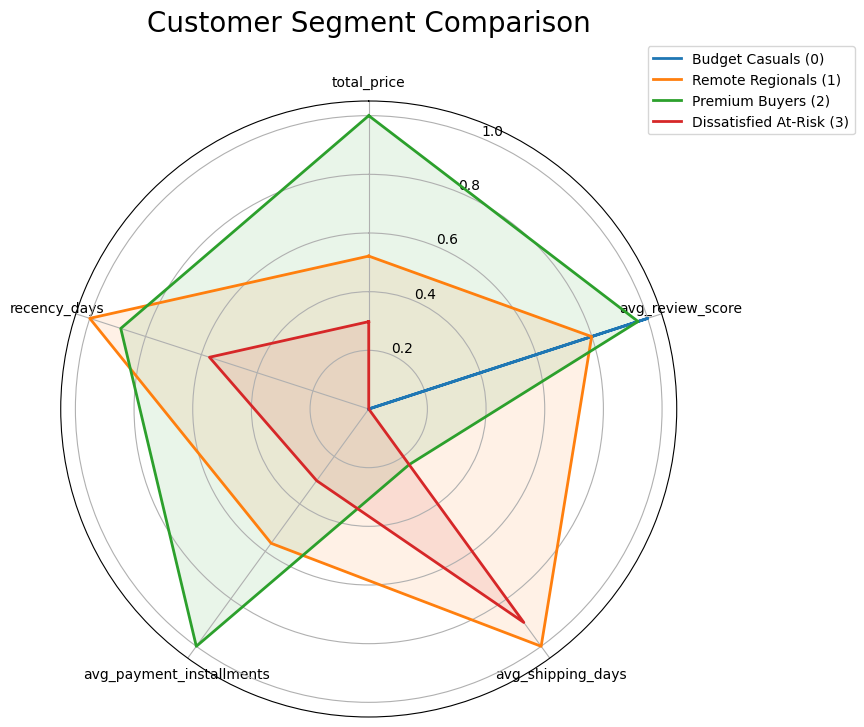

In [33]:


# 1. Define categories and extracted data from your profile table
categories = ['total_price', 'avg_review_score', 'avg_shipping_days', 'avg_payment_installments', 'recency_days']
data = {
    'Budget Casuals (0)': [67.163, 4.652, 8.827, 1.793, 227.471],
    'Remote Regionals (1)': [168.274, 4.042, 20.078, 3.429, 249.024],
    'Premium Buyers (2)': [261.122, 4.547, 11.464, 4.684, 246.628],
    'Dissatisfied At-Risk (3)': [124.924, 1.617, 18.947, 2.666, 239.776]
}

# 2. Scale 0-1 so all metrics fit on one radar
scaler = MinMaxScaler()
df_radar = pd.DataFrame(data, index=categories).T
df_scaled = pd.DataFrame(scaler.fit_transform(df_radar), columns=categories, index=df_radar.index)

# 3. Plotting logic
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1] # close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (label, row) in enumerate(df_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=label)
    ax.fill(angles, values, color=colors[i], alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)
plt.title('Customer Segment Comparison', size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

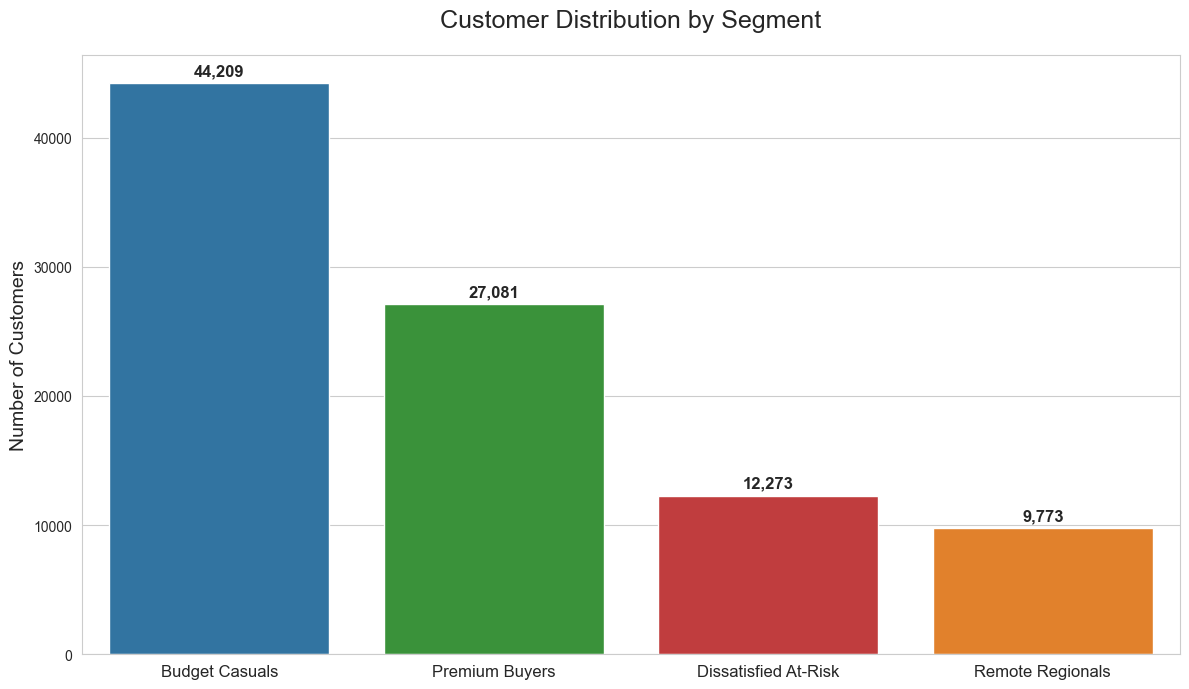

In [34]:

# Define the persona names mapping
persona_map = {
    0: 'Budget Casuals',
    1: 'Remote Regionals',
    2: 'Premium Buyers',
    3: 'Dissatisfied At-Risk'
}

# 1. Get counts and map names
cluster_counts = modified_df['cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Count']
cluster_counts['Persona'] = cluster_counts['Cluster'].map(persona_map)

# 2. Sort for better visualization
cluster_counts = cluster_counts.sort_values('Count', ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Use the same color palette as your radar chart for consistency
palette = {'Budget Casuals': '#1f77b4', 'Remote Regionals': '#ff7f0e', 
           'Premium Buyers': '#2ca02c', 'Dissatisfied At-Risk': '#d62728'}

ax = sns.barplot(data=cluster_counts, x='Persona', y='Count', palette=palette)

# 4. Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Customer Distribution by Segment', fontsize=18, pad=20)
plt.ylabel('Number of Customers', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# 1. Top 3 Categories per Cluster
top_categories = modified_df.groupby('cluster')['favourite_category'].value_counts().groupby(level=0).head(3)

# 2. Dominant Payment Mode per Cluster
top_payments = modified_df.groupby('cluster')['dominant_payment_mode'].value_counts().groupby(level=0).head(1)

print("--- Top 3 Categories per Cluster ---")
print(top_categories)
print("\n--- Dominant Payment Mode per Cluster ---")
print(top_payments)

--- Top 3 Categories per Cluster ---
cluster  favourite_category   
0        health_beauty            4427
         sports_leisure           3693
         computers_accessories    3438
1        health_beauty            1145
         watches_gifts             768
         sports_leisure            716
2        bed_bath_table           3360
         furniture_decor          2224
         housewares               1985
3        bed_bath_table           1576
         computers_accessories    1019
         health_beauty             992
Name: count, dtype: int64

--- Dominant Payment Mode per Cluster ---
cluster  dominant_payment_mode
0        credit_card              31909
1        credit_card               7582
2        credit_card              22912
3        credit_card               9103
Name: count, dtype: int64


### Geographic Distribution

The scatter plot below maps each customer by their coordinates, colored by segment — revealing the geographic dimension of clustering, particularly the Northeast concentration of Remote Regionals.


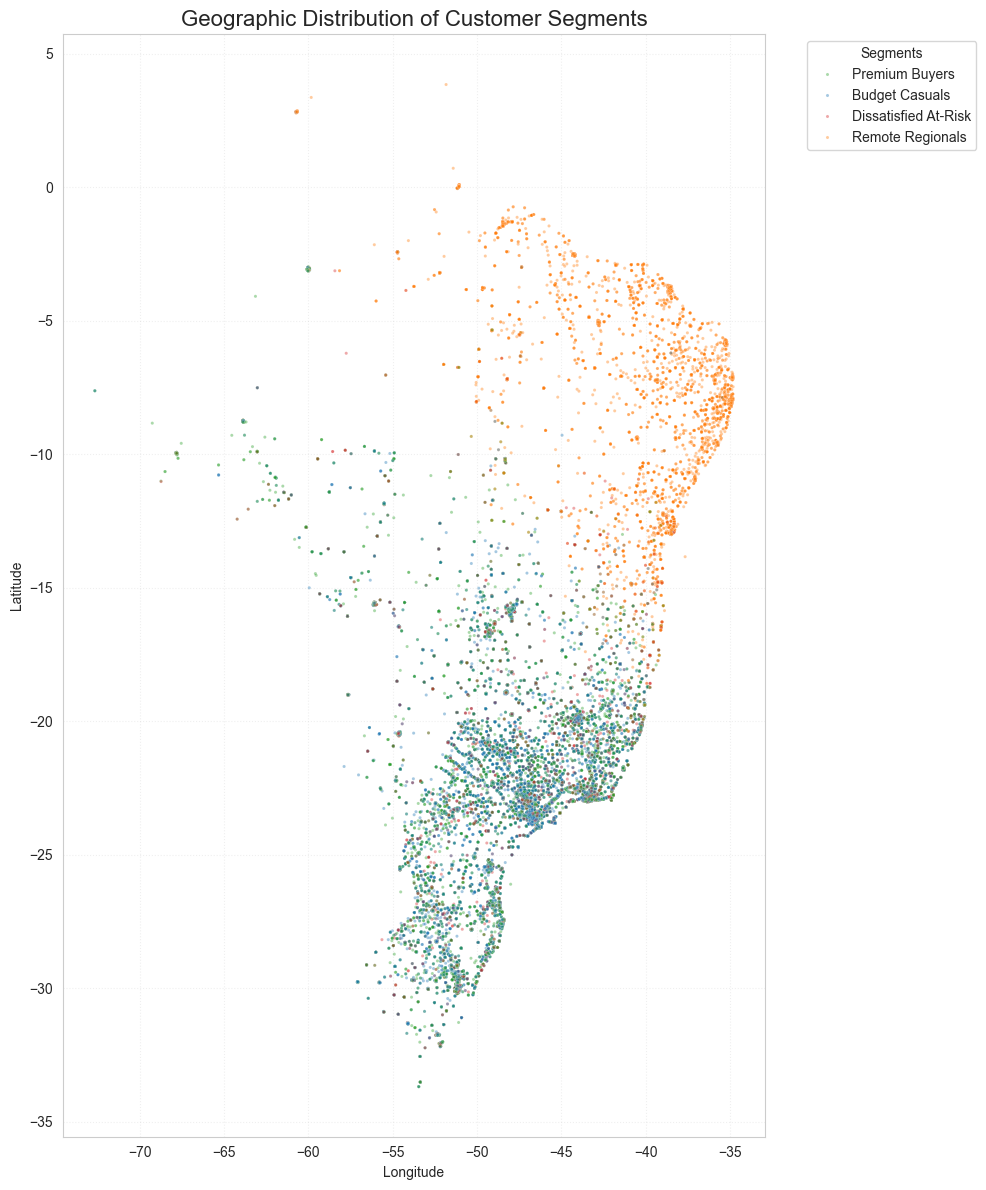

In [36]:

# 1. Define the persona map for the legend
persona_map = {
    0: 'Budget Casuals',
    1: 'Remote Regionals',
    2: 'Premium Buyers',
    3: 'Dissatisfied At-Risk'
}
modified_df['Persona'] = modified_df['cluster'].map(persona_map)

# 2. Plotting
plt.figure(figsize=(10, 12))

# Using a scatter plot with small markers and alpha to handle 93k points
sns.scatterplot(
    data=modified_df, 
    x='longitude', 
    y='latitude', 
    hue='Persona', 
    palette={'Budget Casuals': '#1f77b4', 'Remote Regionals': '#ff7f0e', 
               'Premium Buyers': '#2ca02c', 'Dissatisfied At-Risk': '#d62728'},
    s=5, 
    alpha=0.4
)

# 3. Aesthetics
plt.title('Geographic Distribution of Customer Segments', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')

# Optional: Add a subtle grid
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

## Export

Exporting the final customer-level dataframe with cluster labels for downstream use (Power BI dashboard, CRM integration, targeted campaign lists).


In [37]:
modified_df.to_csv('customer_segments.csv', index=False)

In [38]:

# Create the folder if it doesn't exist
output_dir = '../visuals/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Save Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(modified_df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig(f'{output_dir}correlation_matrix.png', bbox_inches='tight')
plt.close()

# 2. Save Cluster Size Bar Chart
plt.figure(figsize=(12, 7))
sns.countplot(data=modified_df, x='Persona', palette=palette)
plt.title('Customer Distribution by Segment')
plt.savefig(f'{output_dir}cluster_distribution.png', bbox_inches='tight')
plt.close()

# 3. Save Geo Scatter Plot
plt.figure(figsize=(10, 12))
sns.scatterplot(data=modified_df, x='longitude', y='latitude', hue='Persona', palette=palette, s=5, alpha=0.4)
plt.title('Geographic Distribution')
plt.savefig(f'{output_dir}geographic_scatter.png', bbox_inches='tight')
plt.close()

# 4. Save Radar Chart
# (Note: Re-run your radar plotting code here, but use fig.savefig instead of plt.show)
fig.savefig(f'{output_dir}cluster_radar_chart.png', bbox_inches='tight')

print(f"All 4 images successfully saved to {output_dir}")


All 4 images successfully saved to ../visuals/
